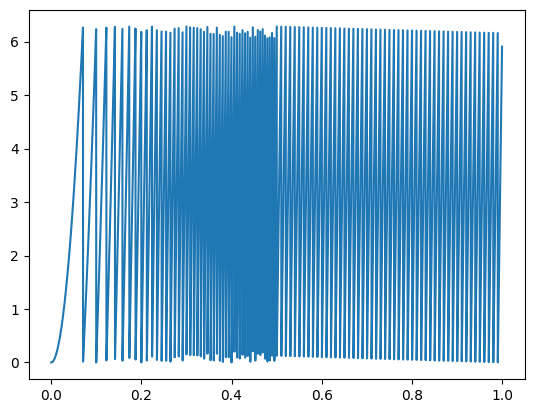

In [9]:
# In this module I'm messing around with a very naive speed estimator using the derivative of position.
# I read in AN2590 that after the Luenberger observer has a position estimate, a heavily filtered derivative
# can be used to get the speed. I tried out a simple approach on HW and actually saw something promising,
# though it was extremely noisy. Since the position is just a sawtooth wave, I can re-create that here and
# mess around with the parameters without running the HW.

import numpy as np
import matplotlib.pyplot as plt

duration = 1.0  # duration of the wave in seconds
fs = 5000  # sampling rate, Hz
f_start = 0  # starting frequency, Hz
f_end = 100.0  # ending frequency, Hz

# Generate a frequency curve of a linear ramp followed by a constant frequency
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
linear_ramp = 2 * np.pi * np.linspace(f_start, f_end, int(fs * duration / 2), endpoint=False)
const_freq = linear_ramp[-1] * np.ones(int(fs * duration / 2))
f_curve = np.concatenate((linear_ramp, const_freq))

# From the frequency curve, generate a sawtooth wave representing the estimated position of the rotor
pos = np.mod(t * f_curve, 2 * np.pi)

# Plot the sawtooth wave
plt.plot(t, pos)
plt.show()

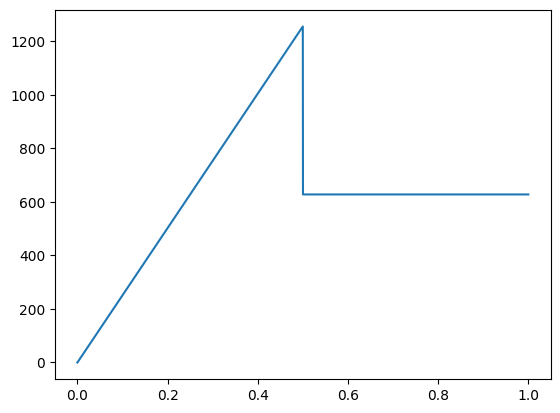

In [10]:
# Compute the derivative of the sawtooth wave
dPos = np.zeros(len(pos))
for i in range(1, len(pos)):
    dt = t[i] - t[i - 1]
    dtheta = pos[i] - pos[i - 1]

    # Wrap the derivative to the range -pi to pi
    while dtheta > np.pi:
        dtheta -= 2 * np.pi
    while dtheta < -np.pi:
        dtheta += 2 * np.pi

    dPos[i] = dtheta / dt

# Plot the derivative of the sawtooth wave
plt.plot(t, dPos)
plt.show()